# Pie charts for the elements in a line list


In [1]:
import specpolFlow as pol
import matplotlib.pyplot as plt
import numpy as np

In this tutorial, we demonstrate how to visualize the distribution of spectral lines from different chemical elements within a specific wavelength range, based on a line mask created with VALD.


In the example below, we use the line mask created in the [Mask Class Tutorial](3-MaskClass_Tutorial.ipynb).




In [2]:
# Load the line mask
mask = pol.read_mask('ExcludeMaskRegionsClass_tutorialfiles/T27000G35_depth0.02.mask')

The [plot_elementsChart](plot_elementsChart) function needs the arguments `mask`, and can use `wmin` and `wmax` to limit the wavelength range used. You can also tweak the optional arguments `plotStyle`, `sort`, and `threshold`. 
- `mask` is a line mask object containing the spectral line data you want to visualize.
- `wmin` is a float that sets the minimum wavelength.
- `wmax` is a float that sets the maximum wavelength.
- `plotStyle` is a string that determines the type of chart to generate. Options are `'pie'` or `'bar'`.
- `sort` is a string that controls the order in which the elements appear in the plot. You can choose:
    - `'Z'` or `'atomic'`: Sort elements by atomic number.
    - `'A'` or `'ascending'`: Sort by increasing number of lines per element.
    - `'D'` or `'descending'`: Sort by decreasing number of lines per element.
- `threshold` is either a float or None. It sets the minimum fractional contribution required for an element to be individually shown in the pie chart. Elements below this threshold are grouped together in an _Other_ category. Default is None, which includes all elements.
- `colors` is a list of colors used for the pie or bar plot.  
- `ax`: an optional matplotlib axes object. If you provide one, the plot will be drawn on it. If not, a new figure and axes will be created automatically.


The example below shows how to plot a pie chart of the elements distribution sorted by the atomic number.

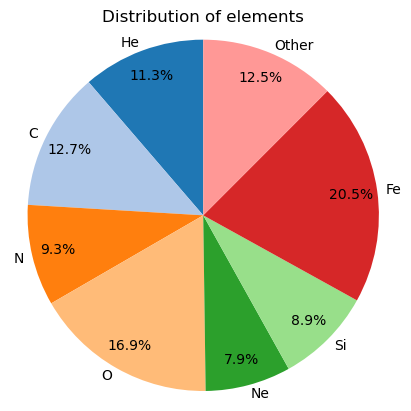

In [3]:
# Plot elements pie chart
pol.plot_elementsChart(mask, sort='Z', threshold=0.05)
plt.show()

Below we illustrate how to use the bar plot with an ascending option for the sorting method.  Here we only use lines between 600 and 710 nm.  Note that the _Other_ category will always be last item in the plot, regardless of the sorting method.

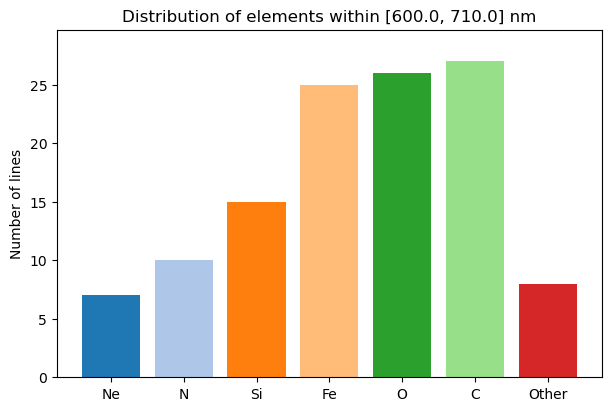

In [4]:
# Set wavelength range of lines considered
wmin = 600.0
wmax = 710.0   

# Plot elements pie chart
pol.plot_elementsChart(mask, wmin, wmax,plotStyle='bar', sort='A', threshold=0.05)
plt.show()

The color palette of the figure can be set by passing a list colors with the `colors` argument.  These can be any colors matplotlib recognizes (see matplotlib's [named colors](https://matplotlib.org/stable/gallery/color/named_colors.html) and [color sequences](https://matplotlib.org/stable/gallery/color/color_sequences.html)).

The figure can be drawn into an existing matplotlib axes object by passing it with the `ax` argument.  The `plot_elementsChart` function returns the figure and axes objects it used, which can be useful for making additional modifications to the figure.

Here we illustrate a multi-panel figure with different color schemes, and change the figure titles.

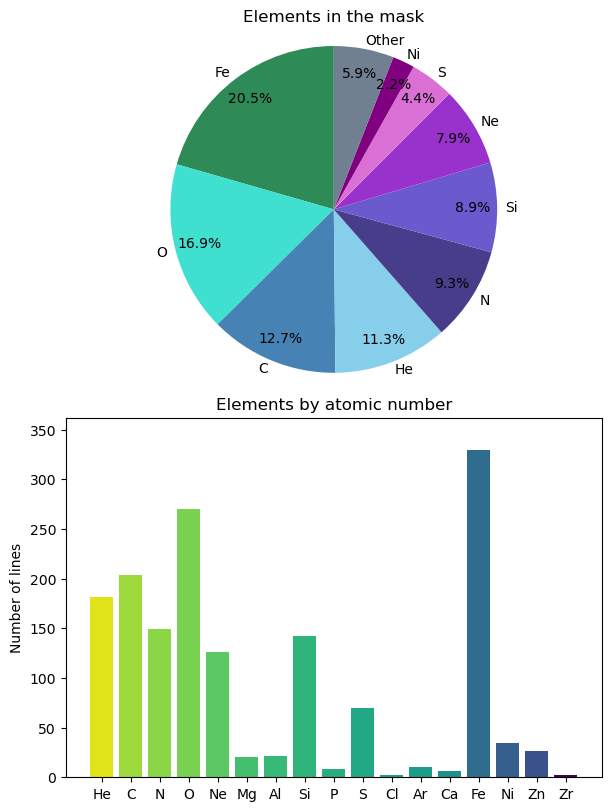

In [5]:
import matplotlib as mpl

# Make a set of axes to draw our figures in
fig, axs = plt.subplots(2,1, layout='constrained', figsize=(6,8))
# Generate the left panel figure
fig1, ax1 = pol.plot_elementsChart(mask, plotStyle='pie', sort='D', threshold=0.02, ax=axs[0],
                                   colors=['seagreen', 'turquoise', 'steelblue', 'skyblue', 'darkslateblue', 
                                           'slateblue', 'darkorchid', 'orchid', 'purple', 'slategrey'])
ax1.set_title('Elements in the mask')

# Get a list of atomic numbers used in the mask
atomicNums = np.unique(np.round(mask.element))
normalizedAtomicNums = atomicNums/np.max(atomicNums)

# Generate the right panel, coloring by atomic number
# (This works because we sort the bar plot by atomic number, 
#  and also provide colors in order of atomic number.)
fig2, ax2 = pol.plot_elementsChart(mask, plotStyle='bar', sort='Z', ax=axs[1],
                                   colors=mpl.colormaps['viridis_r'](normalizedAtomicNums))
ax2.set_title('Elements by atomic number')
plt.show()

If you have a `LineList` object and want to generate one of these plots for it, you can convert it to a `Mask` object and then use this function:
```
mask = pol.convert_list_to_mask(lineList, includeNoLande=True)
pol.plot_elementsChart(mask, plotStyle='pie', sort='D')
```